In [ ]:
pip install ipympl

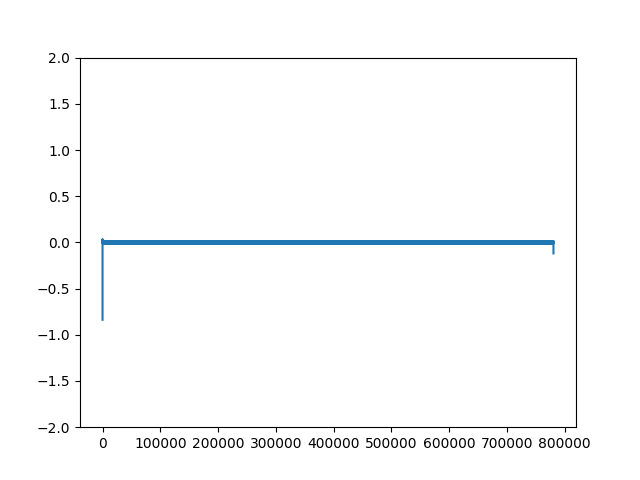

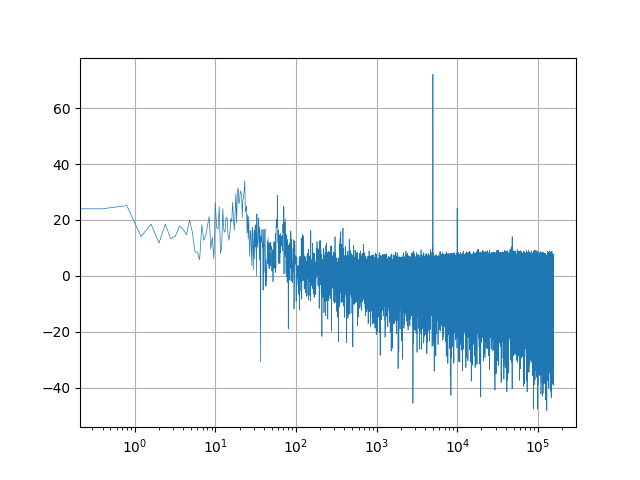

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

%matplotlib widget

filename = "pdm32bits-rtos_5khz_alto01.RAW"
fs = 5e6
fc = 9e4
decim = 16
order = 2

# data
data = np.fromfile(filename, dtype=np.uint32)
data = data[len(data)//2:]
data = data.byteswap()
data2 = data.view(np.uint8)
bits = np.unpackbits(data2)
pdm_signal = 2 * bits.astype(np.float64) - 1

# filtragem
norm_fc = fc / (fs * 0.5)
b, a = butter(N=order, Wn=norm_fc, btype='low')
filtered_data = filtfilt(b, a, pdm_signal)
fs_decim = int(fs / decim)
pcm_signal = filtered_data[::decim]

# sinal pcm no tempo
fig, ax = plt.subplots()
plt.plot(pcm_signal)
ax.set_ylim([-2,2])
plt.show()
# fft & plot
N = len(pcm_signal)
spec = np.abs(np.fft.rfft(pcm_signal))
freq = np.fft.rfftfreq(N, 1/fs_decim)
fig,ax = plt.subplots()
ax.semilogx(freq, 20*np.log10(spec + 1e-12), linewidth=0.5)
plt.grid(True)
plt.show()

In [ ]:
wave.shape

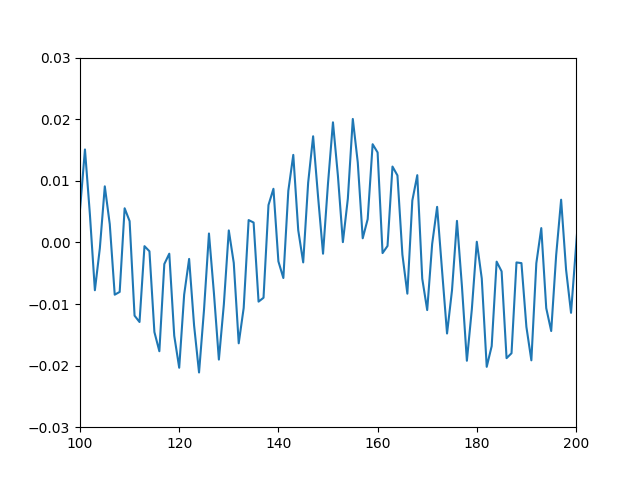

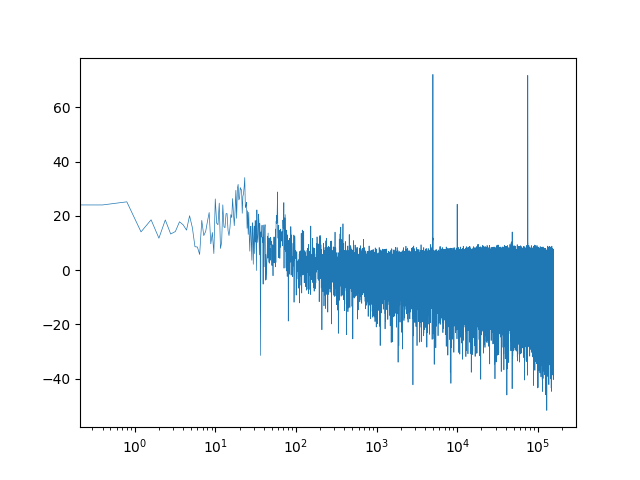

In [2]:
# sinal simulado
t = np.arange(N)/fs_decim
wave = np.sin(2*np.pi*75000*t)/100

sum_wave = (wave + pcm_signal)

fig, ax = plt.subplots()
plt.plot(sum_wave)
ax.set_ylim([-0.03,0.03])
ax.set_xlim([100,200])
plt.show()

N = len(sum_wave)
spec = np.abs(np.fft.rfft(sum_wave))
freq = np.fft.rfftfreq(N, 1/fs_decim)
fig,ax = plt.subplots()
ax.semilogx(freq, 20*np.log10(spec + 1e-12), linewidth=0.5)
plt.show()